![FaMAF-UNC](https://drive.google.com/uc?export=download&id=1k4tzcXOoq6TrkDEW_Ox8o4Y4pAHzKHb7
)
> Docentes: **Damián Fernández** y **Leandro Milne**
>> Teórico del 19-05-2021


# Integración múltiple

## Cambio de variables

Recordemos que si $T:\mathbb{R}^n \to \mathbb{R}^n$ es continuamente diferenciable e inyectiva en $D\subset \mathbb{R}^n$ y $f:\mathbb{R}^n \to \mathbb{R}$ es continua y acotada en $T(D)$, entonces
$$
  \int_{T(D)} f(y) dy = \int_D f(T(x)) \left|\det\bigl(T'(x) \bigr) \right| dx.
$$





#### Ejemplo

Se desea calcular
$$
  \int_D \log(x_1^2 + x_2^2) dx_1 dx_2,
$$
donde
$$
D=\left\{x\in\mathbb{R}^2 \bigm|  a\leq \sqrt{x_1^2 + x_2^2} \leq b, x_1\geq 0, x_2\geq 0 \right\}, \quad 0<a<b,
$$

Considere la transformación $T:\mathbb{R}^2 \to \mathbb{R}^2$ tal que $T(r, \theta) = \bigl(r \cos(\theta), r \operatorname{sen}(\theta) \bigr)$, o sea $(x_1,x_2)=T(r,\theta)$. Luego, si $R=[a,b] \times [0, \pi/2]$ entonces $T(R) = D$.



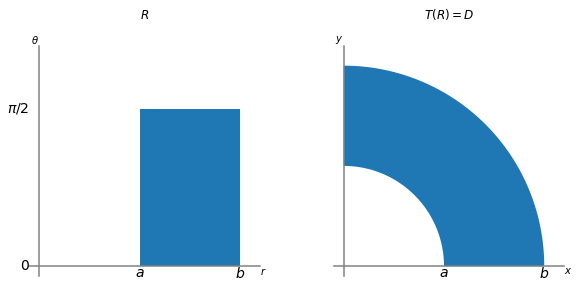

In [ ]:
#@title Cambio de variable { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
a = 1
b = 2
r = np.linspace(a,b,100)
th = np.linspace(0,np.pi/2,100)

ax1.plot([-0.1,1.1*r[-1]], [0,0], color=(0.5, 0.5, 0.5))
ax1.plot([0,0], [-0.1,1.1*r[-1]], color=(0.5, 0.5, 0.5))
ax1.text(1.1*r[-1], 0, '$r$', verticalalignment='top', horizontalalignment='left')
ax1.text(r[0], 0, '$a$', verticalalignment='top', horizontalalignment='center', fontsize=14)
ax1.text(r[-1], 0, '$b$', verticalalignment='top', horizontalalignment='center', fontsize=14)
ax1.text(0, 1.1*r[-1], r'$\theta$', verticalalignment='bottom', horizontalalignment='right')
ax1.text(-0.1, th[0], '0', verticalalignment='center', horizontalalignment='right', fontsize=14)
ax1.text(-0.1, th[-1], r'$\pi/2$', verticalalignment='center', horizontalalignment='right', fontsize=14)
ax1.fill([r[0], r[-1], r[-1], r[0]], [th[0], th[0], th[-1], th[-1]])
ax1.set_title('$R$')
ax1.axis('equal')
ax1.axis('off')

ax2.plot([-0.1,1.1*r[-1]], [0,0], color=(0.5, 0.5, 0.5))
ax2.plot([0,0], [-0.1,1.1*r[-1]], color=(0.5, 0.5, 0.5))
ax2.text(1.1*r[-1], 0, '$x$', verticalalignment='top', horizontalalignment='left')
ax2.text(r[0], 0, '$a$', verticalalignment='top', horizontalalignment='center', fontsize=14)
ax2.text(r[-1], 0, '$b$', verticalalignment='top', horizontalalignment='center', fontsize=14)
ax2.text(0, 1.1*r[-1], '$y$', verticalalignment='bottom', horizontalalignment='right')
ax2.fill(np.concatenate((r[0]*np.cos(th),r[-1]*np.flip(np.cos(th)))), np.concatenate((r[0]*np.sin(th),r[-1]*np.flip(np.sin(th)))))
ax2.set_title('$T(R)=D$')
ax2.axis('equal')
ax2.axis('off');
#plt.savefig('ejm_cambVar1.pdf')

Además
$$
T'(r, \theta) = \left[\begin{array}{cc}
  \cos(\theta) & -r\operatorname{sen}(\theta) \\
  \operatorname{sen}(\theta) & r \cos(\theta)
  \end{array} \right].
$$
Como $\det(T'(r,\theta)) = r\cos^2(\theta) + r \operatorname{sen}^2(\theta) = r$, entonces
\begin{align*}
\int_D \log(x_1^2 + x_2^2) dx_1 dx_2 & = \int_{T(R)} \log(x_1^2 + x_2^2) dx_1 dx_2 \\
  &= \int_R \log(r^2\cos^2(\theta)+r^2 \operatorname{sen}^2(\theta)) |r|  dr d\theta \\
  &=\int_0^{\pi/2} \int_a^b r \log(r^2) dr d\theta \\
  &= \frac{\pi}{2} \int_a^b r \log(r^2) dr
  = \pi \int_a^b r \log(r) dr \\
  &= \pi \left[ \frac{r^2}{2}\log(r) - \frac{r^2}{4} \right]_a^b \\
  &= \pi \left(\frac{b^2}{2}\log(b)- \frac{a^2}{2}\log(a) - \frac{b^2-a^2}{4}\right)
\end{align*}

---


Cuando se integra en un variable, la técnica usal es escoger un cambio de variable tomando en cuenta la función que se desea integrar. Eso puede realizarse sin problema ya que seguramente la función escogida lleva intervalos en intervalos. Cuando se trabaja en varias variables es útil escoger un cambio de variables que transforme la región de integración en una más simple.


#### Ejemplo

Considere que se desea calcular
$$
  \int_D (x_1^2 - x_2^2) e^{x_1 x_2} dx_1 dx_2,
$$
donde $D$ es la región del primer cuadrante del plano entre las hipérbolas $x_1 x_2 =1$, $x_1 x_2 =4$ y las rectas $x_2=x_1$ y $x_2 = x_1+2$.



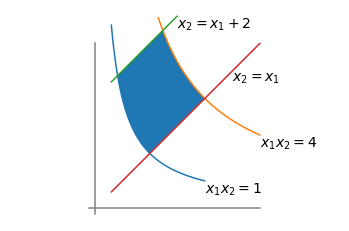

In [ ]:
#@title Región D { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.3,3,200)
h1 = 1/x
h2 = 4/x
r1 = x + 2
r2 = x
fl = np.maximum(r2, h1)
fu = np.minimum(r1, h2)
plt.plot([-0.1,3], [0,0], color=(0.5,0.5,0.5))
plt.plot([0,0], [-0.1,3], color=(0.5,0.5,0.5))
plt.plot(x[h1>0.5], h1[h1>0.5], x[h2 <3.5], h2[h2<3.5], x[r1<3.5], r1[r1<3.5], x, r2)
plt.text(2, 0.5, '$x_1 x_2 = 1$', fontsize=14, verticalalignment='top', horizontalalignment='left')
plt.text(3, 4/3, '$x_1 x_2 = 4$', fontsize=14, verticalalignment='top', horizontalalignment='left')
plt.text(1.5, 3.5, '$x_2 = x_1 + 2$', fontsize=14, verticalalignment='top', horizontalalignment='left')
plt.text(2.5, 2.5, '$x_2 = x_1$', fontsize=14, verticalalignment='top', horizontalalignment='left')
plt.fill_between(x,fl, fu, where=(fu > fl))
plt.axis('equal')
plt.axis('off');
#plt.savefig('ejm_cambVar2.pdf')

El cambio de variable motivado por el integrando sería
$$
  v_1 = x_1^2 - x_2^2, \quad v_2 = x_1 x_2,
$$
pero ésto no parece ser adecuado para reescribir $D$. Motivado por las curvas que definen $D$ el cambio de variable sería
$$
  u_1 = x_1 x_2 , \quad u_2 = x_2 - x_1.
$$
Con esto, si definimos $T$ tal que $T(u) = x$ entonces $D=T(R)$ para
$$
  R=[1,4] \times [0,2].
$$
Como $u=T^{-1}\bigl( T(u)\bigr)$ entonces $I = (T^{-1})'\bigl( T(u)\bigr) T'(u)$ y $\det\bigl((T^{-1})'(T(u)) \bigr) \det(T'(u)) = 1$. Como
$$
T^{-1}(x) = \left[\begin{array}{c} x_1 x_2 \\ x_2 - x_1\end{array} \right], \qquad
(T^{-1})'(x) = \left[\begin{array}{cc} x_2 & x_1 \\ -1 & 1\end{array} \right],
$$
entonces $\det\bigl((T^{-1})'(x) \bigr) = x_1 + x_2$
\begin{align*}
  \int_D (x_1^2 - x_2^2) e^{x_1 x_2} dx_1 dx_2
  &=  \int_D (x_1 - x_2) e^{x_1 x_2} (x_1 + x_2) dx_1 dx_2 \\
  &=  \int_D (x_1 - x_2) e^{x_1 x_2} |\det\bigl((T^{-1})'(x) \bigr)| dx_1 dx_2 \\
  &= \int_0^2 \int_1^4 (-u_2) e^{u_1} |\det\bigl((T^{-1})'(T(u)) \bigr)| |\det(T'(u))|du_1 du_2 \\
  &= \int_0^2 \int_1^4 (-u_2) e^{u_1} du_1 du_2 \\
  &= - \int_0^2 u_2 (e^4 - e^1) du_2 \\
  &= -2(e^4-e^1).
\end{align*}


## Integrales impropias


En muchas ocasiones se necesita integrar funciones sobre un conjunto donde la función no es acotada, el conjunto no es acotado o ambos son no acotados. La manera de realizar el cálculo será tomando una familia de conjuntos acotados que en cierto sentido converge al conjunto original. Veamos algunos ejemplos.

#### Ejemplo

Sea $D=[1,\infty) \times [0,1]$ y se desea calcular
$$
    \int_D e^{-x_1 x_2} - 2 e^{-2x_1 x_2} dx_1 dx_2.
$$
Consideremos $D_{n,\varepsilon} = [1,n] \times [\varepsilon,1]$ con $n>2$ y $\varepsilon<1/2$, luego el orden de integración puede intercambiarse y
\begin{align*}
    \int_{D_{n,\varepsilon}}\!\! e^{-x_1 x_2} - 2 e^{-2x_1 x_2} dx_1 dx_2
    &= \int_\varepsilon^1 \int_1^n e^{-x_1 x_2} - 2 e^{-2x_1 x_2} dx_1 dx_2 \\
    &= \int_1^n \int_\varepsilon^1  e^{-x_1 x_2} - 2 e^{-2x_1 x_2}  dx_2 dx_1\\
    &= \int_1^n \left[-\frac{1}{x_1} e^{-x_1 x_2} +\frac{1}{x_1} e^{-2x_1 x_2}\right]_{x_2=\varepsilon}^{x_2=1}  dx_1\\
    &= \int_1^n -\frac{1}{x_1} e^{-x_1} +\frac{1}{x_1} e^{-2x_1} +\frac{1}{x_1} e^{-\varepsilon x_1} - \frac{1}{x_1} e^{-2\varepsilon x_1}  dx_1\\
    &=  -\int_1^n \frac{e^{-s}}{s}  ds
        +\int_2^{2n} \frac{e^{-s}}{s}  ds
        +\int_\varepsilon^{n\varepsilon} \frac{e^{-s}}{s}  ds
        -\int_{2\varepsilon}^{2n\varepsilon} \frac{e^{-s}}{s}   ds\\
    &=  -\int_1^2 \frac{e^{-s}}{s} ds
        +\int_n^{2n} \frac{e^{-s}}{s} ds
        +\int_\varepsilon^{2\varepsilon} \frac{e^{-s}}{s}  ds
        -\int_{n\varepsilon}^{2n\varepsilon} \frac{e^{-s}}{s}   ds\\
    &=  -\int_1^2 \frac{e^{-t}}{t} dt
        +\int_1^{2} \frac{e^{-nt}}{t} dt
        +\int_1^{2} \frac{e^{-\varepsilon t}}{t} dt
        -\int_{1}^{2} \frac{e^{-n\varepsilon t}}{t} dt,
\end{align*}
donde en la quinta y séptima igualdad se usó que para $\phi(t)=ct$ con $c>0$,
$$
    \int_{ca}^{cb} \frac{1}{s} e^{-s} ds
    = \int_a^b \frac{1}{\phi(t)} e^{-\phi(t)} |\phi'(t)| dt
    = \int_a^b \frac{1}{t}e^{-ct} dt.
$$
Note que para cualquier $\alpha>0$ la función $t\mapsto e^{-\alpha t}$ es decreciente. Por lo tanto
$$
    e^{-2\alpha} \log(2) = \int_1^2 \frac{e^{-2\alpha}}{x} dx
                \leq \int_1^2 \frac{e^{-\alpha x}}{x} dx
                \leq \int_1^2 \frac{e^{-\alpha}}{x} dx = e^{-\alpha} \log(2),
$$
luego
$$
 \lim_{\alpha \to 0} \int_1^2 \frac{e^{-\alpha x}}{x} dx = \log(2), \qquad
 \lim_{\alpha \to \infty} \int_1^2 \frac{e^{-\alpha x}}{x} dx = 0.
$$

Concluyendo que
$$
\int_0^1 \left( \int_1^\infty e^{-x_1 x_2} - 2 e^{-2x_1 x_2} dx_1 \right) dx_2
                = \log(2) -  \int_1^2 \frac{e^{-t}}{t}  dt,
$$
y
$$
\int_1^\infty \left( \int_0^1 e^{-x_1 x_2} - 2 e^{-2x_1 x_2} dx_2 \right) dx_1
                = -  \int_1^2 \frac{e^{-t}}{t}  dt.
$$

---

Se dice que una función $f$ tiene un punto de discontinuidad infinita en $\bar{x}$ si $|f(x)| \to \infty$ cuando $x\to \bar{x}$. Veamos un ejemplo con un punto de este tipo.

#### Ejemplo

Para $D=\{x\in \mathbb{R}^2 \mid \|x\| \leq 1\}$ se desea calcular
$$
    \int_D -\log(\|x\|^2) dx.
$$


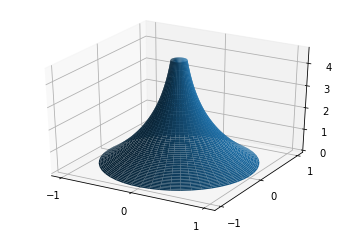

In [ ]:
#@title Log radial { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

ax = plt.axes(projection='3d')
r = np.linspace(0.1, 1, 50)
th = np.linspace(0, 2*np.pi, 50)
x1 = np.outer(r, np.cos(th))
x2 = np.outer(r, np.sin(th))
x3 = np.outer(-np.log(r**2), np.ones(th.shape))
ax.plot_surface(x1, x2, x3)
ax.set_xticks([-1, 0, 1])
ax.set_yticks([-1, 0, 1]);
#plt.savefig('ejm_logradial.pdf')

Claramente la función a integrar tiene un punto de discontinuidad infinita en el origen. Para aislar la discontinuidad, definimos $D_\varepsilon = \{x\in \mathbb{R}^2 \mid \varepsilon \leq \|x\| \leq 1\}$. Considerando coordenadas polares, i.e., $T(r,\theta)=\bigl( r\cos(\theta), r\operatorname{sen}(\theta)\bigr)$, tenemos que $D_\varepsilon = T([\varepsilon,1] \times [0, 2\pi])$. Por lo tanto, como $\det(T'(r,\theta))=r$,
\begin{align*}
    \int_{D_\varepsilon} -\log(\|x\|^2) dx
    &=\int_\varepsilon^1 \int_0^{2\pi} -r \log(r^2) d\theta dr \\
    &=-4 \pi \int_\varepsilon^1 r \log(r) dr \\
    &=-4 \pi \left[ \frac{r^2}{2}\log(r) - \frac{r^2}{4} \right]_{r=\varepsilon}^{r=1} \\    
    &=  \pi + 2 \pi \varepsilon^2\log(\varepsilon) - \pi\varepsilon^2 .
\end{align*}
Luego
$$
    \int_D -\log(\|x\|^2) dx = \lim_{\varepsilon \to 0^+} \int_{D_\varepsilon} -\log(\|x\|^2) dx = \pi.
$$


---

Diremos que una familia creciente $\{D_\lambda\}_{\lambda \in \Lambda}$ de subconjuntos de $D$ **converge a** $D$, si cada subconjuto acotado de $D$ donde $f$ es acotada está contenido en algún $D_\lambda$.

> **Definición**
>
> Diremos que la **integral impropia** de $f$ sobre $D$ es
$$
    \int_D f(x) dx = \lim_{\lambda \in \Lambda} \int_{D_\lambda} f(x) dx,
$$
cuando el límite existe, es finito y con igual valor para cualquier familia creciente de conjuntos acotados $\{D_\lambda\}_{\lambda \in \Lambda}$ que converge a $D$.




Claramente, verificar que el límite es igual para cualquier familia que converge a $D$ no es algo realizable en la práctica. En algunos casos, podemos obtener algo calculable.


> **Teorema**
>
> Si $f:\mathbb{R}^n \to \mathbb{R}$ satisface $f(x) \geq 0$ para todo $x \in D$ y
 $$
    \lim_{\lambda \in \Lambda} \int_{D_\lambda} f(x) dx,
 $$
 es finito para una familia $\{D_\lambda\}_{\lambda \in \Lambda}$ que converge a $D$, entonces
 $$
    \int_D f(x) dx = \lim_{\xi \in \Xi} \int_{C_\xi} f(x) dx,
$$
para toda familia $\{C_\xi\}_{\xi \in \Xi}$ que converge a $D$.


**Demostración:**

Como tenemos familias crecientes de conjuntos, entonces dado $\lambda_0$ existen $\xi_0$ y $\lambda_1$ tales que
$$
    D_{\lambda_0} \subset C_{\xi_0} \subset D_{\lambda_1}.
$$
Luego, como $f(x)\geq 0$ para todo $x\in D$, entonces
$$
  \int_{D_{\lambda_0}} f(x) dx \leq \int_{C_{\xi_0}} f(x) dx \leq \int_{D_{\lambda_1}} f(x) dx.
$$
Concluyendo que si $\lim_{\lambda \in \Lambda} \int_{D_\lambda} f(x) dx$ existe, entonces el mismo límite se obtiene para la familia $\{C_\xi\}_{\xi \in \Xi}$. $\spadesuit$




Veamos cómo utilizar este resultado.

#### Ejemplo

Se desea calcular
$$
    \int_0^\infty \int_0^1 \frac{e^{-x_1}}{\sqrt{x_2}} dx_2 dx_1.
$$
Como el integrando es no negativo, sólo basta considerar una familia de conjuntos convergentes. Consideremos la familia $D_n = [0,n] \times [1/n, 1]$ para $n\in \mathbb{N}$. Luego
\begin{align*}
    \int_0^n \int_{1/n}^1 \frac{e^{-x_1}}{\sqrt{x_2}} dx_2 dx_1
        &= \left(\int_0^n e^{-x_1} dx_1\right) \left( \int_{1/n}^1 x_2^{-1/2} dx_2 \right) \\
        &= \left[ -e^{-x_1} \right]_0^n \left[ 2 x_2^{1/2} \right]_{1/n}^1 \\
        &= (1-e^{-n})(2-2/\sqrt{n}).
\end{align*}
Concluyendo que
$$
\int_0^\infty \int_0^1 \frac{e^{-x_1}}{\sqrt{x_2}} dx_2 dx_1
    =\lim_{n\to \infty} \int_0^n \int_{1/n}^1 \frac{e^{-x_1}}{\sqrt{x_2}} dx_2 dx_1 = 2.
$$

---


Para funciones no necesariamente no negativas, tenemos el siguiente resultado.

>**Teorema**
>
> Sean $f:\mathbb{R}^n \to \mathbb{R}$ y $g:\mathbb{R}^n \to \mathbb{R}$ con los mismos puntos de discontinuidad infinita y $|f(x)| \leq g(x)$ para todo $x\in D$. Si $\int_D g(x) dx$ existe, entonces $\int_D f(x) dx$ existe.


**Demostración:**

Sea $\{D_\lambda\}_{\lambda \in \Lambda}$ una familia creciente que converge a $D$. Como $-|f(x)| \leq f(x) \leq |f(x)|$, entonces para todo $x\in D$,
$$
0 \leq f(x) + |f(x)| \leq 2 |f(x)| \leq 2 g(x).
$$
Luego, si $\int_D g(x) dx$ existe, entonces
$$
\int_{D_\lambda} (f(x) + |f(x)|) dx \leq 2 \int_{D_\lambda} |f(x)| dx \leq 2 \int_{D_\lambda} g(x) dx \leq 2 \int_{D} g(x) dx.
$$
Como las integrales sobre $D_\lambda$ son crecientes y acotadas superiormente, tenemos que existen
$$
\ell_1 = \lim_{\lambda \in \Lambda} \int_{D_\lambda}(f(x) + |f(x)|) dx, \qquad
\ell_2 = \lim_{\lambda \in \Lambda} \int_{D_\lambda} |f(x)| dx.
$$
Con esto,
\begin{align*}
    \lim_{\lambda \in \Lambda} \int_{D_\lambda} f(x) dx
        &=\lim_{\lambda \in \Lambda}\left( \int_{D_\lambda} (f(x) + |f(x)|) dx - \int_{D_\lambda} |f(x)| dx \right)\\
        &=\lim_{\lambda \in \Lambda} \int_{D_\lambda} f(x) + |f(x)| dx - \lim_{\lambda \in \Lambda} \int_{D_\lambda} |f(x)| dx = \ell_1 - \ell_2.
\end{align*}
Como la familia $\{D_\lambda\}_{\lambda \in \Lambda}$ es arbitraria, obtenemos que existe $\int_D f(x) dx$. $\spadesuit$




El siguiente ejemplo nos permite aplicar este resultado.

#### Ejemplo

Sea $D=\{x\in\mathbb{R}^2 \mid \|x\| \leq 1\}$ y $f:\mathbb{R}^2 \setminus\{0\} \to \mathbb{R}$ tal que
$$
    f(x) = \left\{\begin{array}{cc}
         \|x\|^{-1}& \textrm{ si } x_1\geq 0, \, x\neq 0, \\
         -\|x\| & \textrm{ si } x_1<0.
    \end{array} \right.
$$
Veamos que $\int_D f(x) dx$ existe. Como $\|x\|^2 \leq 1$ implica $\|x\| \leq \|x\|^{-1}$, obtenemos que $|f(x)|\leq \|x\|^{-1}$ para todo $x\in D\setminus\{0\}$. Por otro lado
$$
    \int_D \|x\|^{-1} dx = \int_0^1 \int_{-\pi/2}^{3\pi/2} r^{-1} r d\theta dr = 2\pi,
$$
donde se usó el cambio de variables $T(r,\theta) = \bigl(r\cos(\theta), r \operatorname{sen}(\theta) \bigr)$ sobre la región $[0,1]\times [-\pi/2, 3\pi/2]$. Obteniendo del teorema anterior que existe $\int_D f(x) dx$.
Para calcularlo, considerando las regiones $D_n=T\bigl( [1/n,1] \times [-\pi/2,3\pi/2]\bigr)$, se tiene
\begin{align*}
    \int_{D_n} f(x) dx &= \int_{1/n}^1 \int_{-\pi/2}^{3\pi/2} f(r\cos(\theta), r \operatorname{sen}(\theta)) r d\theta dr \\
    &= \int_{1/n}^1 \left( \int_{-\pi/2}^{\pi/2} r^{-1} r d\theta
    + \int_{\pi/2}^{3 \pi/2} (-r^2) d\theta \right) dr \\
    &= \int_{1/n}^1 (\pi - \pi r^2) dr = \pi \left[r - r^3/3 \right]_{1/n}^1 \\
    &= \pi\left( 1- \frac{1}{3} - \frac{1}{n} + \frac{1}{3 n^3}\right).
\end{align*}
Luego
$$
\int_D f(x) dx = \lim_{n \to \infty} \int_{D_n} f(x) dx = \frac{2}{3} \pi.
$$


---